# GestDeck - Cuaderno 02: Arquitectura LSTM, Entrenamiento y Evaluación

Este cuaderno abarca el diseño formal de la red neuronal, su entrenamiento y la evaluación del rendimiento. A partir de los tensores limpios generados en el cuaderno anterior, construiremos una **Recurrente Profunda (Deep LSTM)**.

## 1. Justificación de la Arquitectura Seleccionada

Se ha seleccionado una red **Long Short-Term Memory (LSTM)** porque la naturaleza de los gestos de las manos es **secuencial** a través del tiempo. Un gesto no es una imagen estática, es una evolución de posiciones a lo largo de 30 frames. Las LSTMs pueden "recordar" secuencias a largo plazo y evitar el desvanecimiento de gradientes clásico de las RNN simples.

### Especificación Formal de Entradas y Salidas
- **Tensor de Entrada ($X$)**: `(None, 30, 42)`
  - `None`: Tamaño dinámico del batch.
  - `30`: Timesteps (Resolución temporal de 30 frames por video).
  - `42`: Features (21 landmarks extraídos $\times$ 2 coordenadas espaciales $X, Y$).
- **Profundidad y Normalización**: `float32`, con rango estático dinámico pre-normalizado $[0.0, 1.0]$ heredado del bounding box interno de MediaPipe.
- **Tensor de Salida ($Y$)**: `(None, 9)`
  - Array probabilístico distribuido entre las 9 clases (Softmax).

### Diagrama de Flujo de Datos

```mermaid
graph TD
    A["Video Crudo (.mp4)"] -->|MediaPipe Tasks| B("Tensor 3D (Muestras, 30, 42)")
    B -->|Masking| C["Ignorar frames con ceros"]
    C -->|LSTM 64 units| D["Extracción Temporal Baja"]
    D -->|LSTM 64 units| E["Extracción Temporal Alta"]
    E -->|LSTM 32 units| F["Refinamiento"]
    F -->|Batch Normalization| G["Estabilización de Gradientes"]
    G -->|Dense 32 + ReLU| H["Razonamiento Lógico"]
    H -->|Dense 9 + Softmax| I(("Predicción de Gesto"))
```

In [15]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# TensorFlow / Keras para Arquitectura Profunda
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Evaluación
from sklearn.metrics import confusion_matrix, classification_report

sns.set_theme(style="whitegrid")

# Directorios
FINAL_DATA_DIR = "../dataset/final"
MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

## 2. Carga de los Datos Estratificados
Cargamos los datos que fueron divididos y aumentados meticulosamente en el Cuaderno 01.

In [16]:
# Cargar tensores
X_train = np.load(os.path.join(FINAL_DATA_DIR, "X_train.npy"))
y_train = np.load(os.path.join(FINAL_DATA_DIR, "y_train.npy"))

X_val = np.load(os.path.join(FINAL_DATA_DIR, "X_val.npy"))
y_val = np.load(os.path.join(FINAL_DATA_DIR, "y_val.npy"))

X_test = np.load(os.path.join(FINAL_DATA_DIR, "X_test.npy"))
y_test = np.load(os.path.join(FINAL_DATA_DIR, "y_test.npy"))

with open(os.path.join(FINAL_DATA_DIR, "labels.json"), "r") as f:
    classes = json.load(f)

print(f"Volumen Train: {X_train.shape} | Labels: {y_train.shape}")
print(f"Volumen Val:   {X_val.shape} | Labels: {y_val.shape}")
print(f"Volumen Test:  {X_test.shape} | Labels: {y_test.shape}")

Volumen Train: (252, 30, 42) | Labels: (252,)
Volumen Val:   (11, 30, 42) | Labels: (11,)
Volumen Test:  (11, 30, 42) | Labels: (11,)


## 3. Construcción del Modelo Profundo (Deep Model)

Implementamos 3 capas LSTMs. Añadimos **Batch Normalization** tras la última etapa recurrente para centrar las activaciones, estabilizar los pesos y facilitar la convergencia rápida del optimizador Adam.

In [17]:
model = Sequential([
    # 1. Capa de enmascaramiento para ignorar los paddings (0.0)
    Masking(mask_value=0.0, input_shape=(30, 42)),
    
    # 2. Arquitectura LSTM Profunda (3 Capas)
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    
    # 3. Batch Normalization (Normalización matemática por lote)
    BatchNormalization(),
    
    # 4. Capas Densas Finales
    Dense(32, activation='relu'),
    Dense(len(classes), activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\Carlos Ahumada Soles\OneDrive\Documentos\deep\Proyecto\gestdeck\prodeep\Lib\site-packages\keras\src\layers\core\masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_2 (Masking)             │ (None, 30, 42)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 30, 64)         │        27,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,313 (290.29 KB)

 Trainable params: 74,249 (290.04 KB)

 Non-trainable params: 64 (256.00 B)

## 4. Entrenamiento (Training Pipeline)
Ejecutamos el entrenamiento con un mínimo formal de **50 épocas** y un `EarlyStopping` para prevenir gastar cómputo en vano si la red deja de mejorar. Guardaremos el mejor modelo en `.keras`.

In [18]:
MODEL_PATH = os.path.join(MODELS_DIR, "gestures_model.keras")

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True)
]

print("Iniciando Entrenamiento de la LSTM...")
history = model.fit(
    X_train, y_train,
    epochs=80,             # Permitimos más de 50 épocas dado que tenemos early stopping
    batch_size=16,         # Batch pequeño para datos tabulares ligeros
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)
print("¡Entrenamiento finalizado y modelo guardado!")

Iniciando Entrenamiento de la LSTM...
Epoch 1/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 17s 189ms/step - accuracy: 0.2778 - loss: 1.9058 - val_accuracy: 0.4545 - val_loss: 1.9788
Epoch 2/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.5397 - loss: 1.3513 - val_accuracy: 0.5455 - val_loss: 1.8721
Epoch 3/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.6825 - loss: 1.0744 - val_accuracy: 0.8182 - val_loss: 1.6777
Epoch 4/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.8492 - loss: 0.7283 - val_accuracy: 0.9091 - val_loss: 1.5233
Epoch 5/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.9087 - loss: 0.4828 - val_accuracy: 0.9091 - val_loss: 1.1846
Epoch 6/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.9167 - loss: 0.3650 - val_accuracy: 0.9091 - val_loss: 1.0631
Epoch 7/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9008 - loss: 0.3290 - val_accuracy: 0.9091 - val_loss: 0.9596
Epoch 8/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.9087 -

## 5. Evaluación de Métricas y Profilaje (Profiling)
Visualización de la convergencia y métricas puras usando el 10% del dataset que fue reservado celosamente (`X_test`).

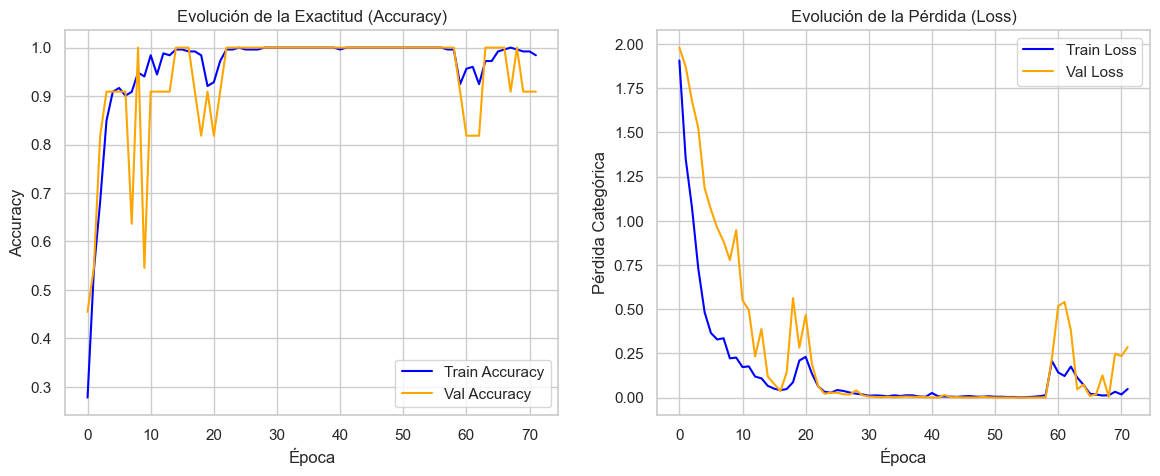

In [19]:
# 5.1 Curvas de Convergencia (Learning Curves)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Evolución de la Exactitud (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Pérdida Categórica')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

=== REPORTE DE CLASIFICACIÓN (Test Set) ===
               precision    recall  f1-score   support

     ANTERIOR       0.00      0.00      0.00         0
       EMPUJE       1.00      1.00      1.00         1
       INDICE       1.00      1.00      1.00         1
PALMA_ABIERTA       1.00      1.00      1.00         2
        PAUSA       1.00      1.00      1.00         2
     PELLIZCO       1.00      1.00      1.00         2
 PELLIZCO_INV       1.00      1.00      1.00         1
 PUNO_CERRADO       1.00      1.00      1.00         2
    SIGUIENTE       0.00      0.00      0.00         0

     accuracy                           1.00        11
    macro avg       0.78      0.78      0.78        11
 weighted avg       1.00      1.00      1.00        11



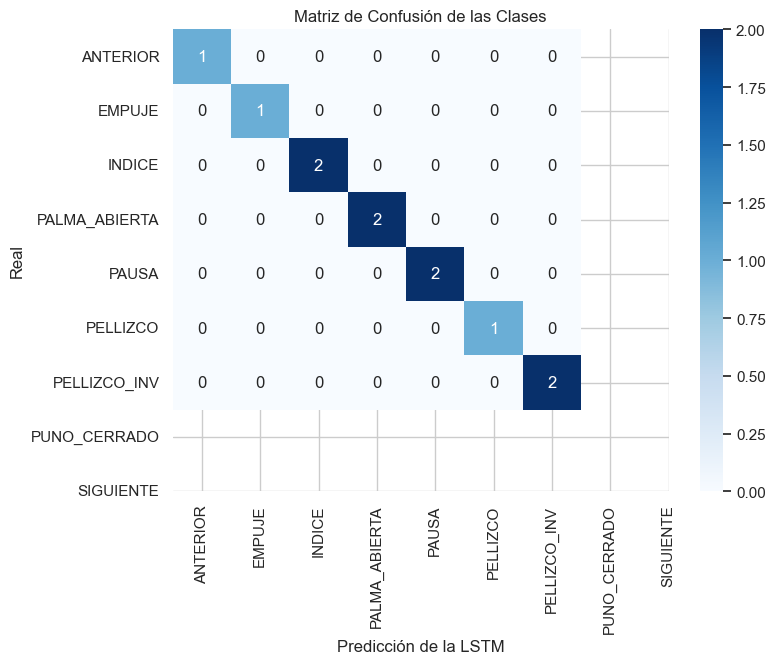

In [20]:
# 5.2 Predicciones sobre el Conjunto de Test (NUNCA VISTO POR EL MODELO)
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 5.3 Classification Report (Precision, Recall, F1)
print("\n=== REPORTE DE CLASIFICACIÓN (Test Set) ===")
print(classification_report(y_test, y_pred, labels=np.arange(len(classes)), target_names=classes, zero_division=0))

# 5.4 Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusión de las Clases')
plt.ylabel('Real')
plt.xlabel('Predicción de la LSTM')
plt.show()

In [21]:
# 5.5 Profilaje: Tamaño y Velocidad
model_size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)

# Medimos la velocidad realizando 100 inferencias sobre una muestra dummy
dummy_input = np.zeros((1, 30, 42))
start_time = time.time()
for _ in range(100):
    _ = model.predict(dummy_input, verbose=0)
end_time = time.time()

inference_speed_ms = ((end_time - start_time) / 100) * 1000

print("=== PROFILAJE DEL MODELO ===")
print(f"Peso físico del modelo: {model_size_mb:.2f} MB")
print(f"Velocidad de Inferencia: {inference_speed_ms:.2f} milisegundos por predicción")

=== PROFILAJE DEL MODELO ===
Peso físico del modelo: 0.91 MB
Velocidad de Inferencia: 202.48 milisegundos por predicción


## 6. Prueba en Vivo (Inferencia del Mundo Real)

Con el modelo ya entrenado y verificado, esta celda te permite probar la red pasándole **cualquier video real**. 
Internamente extraerá los puntos con MediaPipe, los convertirá en un tensor `(1, 30, 42)`, y le pedirá a tu LSTM que dictamine de qué gesto se trata.

In [22]:
import urllib.request
import cv2
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import mediapipe as mp

def predict_video_gesture(video_path):
    if not os.path.exists(video_path):
        print(f"[Error] No se encontró el video en: {video_path}")
        return
        
    # 1. Configurar MediaPipe Tasks
    model_path = "hand_landmarker.task"
    if not os.path.exists(model_path):
        urllib.request.urlretrieve("https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task", model_path)
        
    base_options = python.BaseOptions(model_asset_path=model_path)
    options = vision.HandLandmarkerOptions(
        base_options=base_options,
        num_hands=1,
        min_hand_detection_confidence=0.5,
        min_hand_presence_confidence=0.5
    )
    detector = vision.HandLandmarker.create_from_options(options)
    
    # 2. Extraer Secuencia
    cap = cv2.VideoCapture(video_path)
    frames_features = []
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
            
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
        results = detector.detect(mp_image)
        
        if results.hand_landmarks:
            features = []
            for lm in results.hand_landmarks[0]:
                features.extend([lm.x, lm.y])
            frames_features.append(features)
        else:
            frames_features.append(np.zeros(42).tolist())
            
    cap.release()
    
    if not frames_features:
        print("No se detectaron manos en el video.")
        return
        
    # 3. Transformar al formato de entrada del LSTM
    frames_features = np.array(frames_features)
    if len(frames_features) > 30:
        frames_features = frames_features[:30]
    elif len(frames_features) < 30:
        pad = np.zeros((30 - len(frames_features), 42))
        frames_features = np.vstack((frames_features, pad))
        
    # Añadir dimensión de Batch (1, 30, 42)
    tensor_input = np.expand_dims(frames_features, axis=0)
    
    # 4. Inferencia con LSTM
    prediction = model.predict(tensor_input, verbose=0)
    predicted_class_index = np.argmax(prediction[0])
    confidence = prediction[0][predicted_class_index] * 100
    
    print("\n" + "="*40)
    print(f"🎥 Video Analizado: {os.path.basename(video_path)}")
    print(f"🧠 Gesto Detectado: {classes[predicted_class_index]}")
    print(f"📊 Confianza:       {confidence:.2f}%")
    print("="*40)

# EJEMPLO DE USO:
# Cambia la ruta por la de cualquier video de prueba que desees
# predict_video_gesture("ruta/a/tu/video_de_prueba.mp4")
predict_video_gesture("C:/Users/Carlos Ahumada Soles/OneDrive/Documentos/deep/gestoprueba2.mp4")


🎥 Video Analizado: gestoprueba2.mp4
🧠 Gesto Detectado: PELLIZCO
📊 Confianza:       99.99%
